# Mental Health Text Classification

## Project Overview
This project builds a text classification model to categorise mental health statements into one of seven categories: Bipolar, Suicidal, Personality Disorder, Anxiety, Depression, Stress, and Normal.

The goal is to demonstrate a complete NLP pipeline, from raw text to a deployed, working classifier.

## Dataset
Source: Kaggle :- Sentiment Analysis for Mental Health
Features: statement (raw text), status (mental health category)

## 1. Importing Libraries

Core libraries for data manipulation, NLP preprocessing, modelling, and evaluation.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')



In [8]:
df = pd.read_csv("../data/Sentiment_Mental_health_dataset.csv")
df.head()

,statement,status
0,Anyone else have symptoms much improved after ...,Bipolar
1,"I basicaly do not exist, sure feels that way. ...",Suicidal
2,Finding a sense of self It's like one minute I...,Personality_disorder
3,Putting into words what were just tangles in m...,Anxiety
4,Anxiety makes me worry about my public image s...,Anxiety


In [9]:
df.describe()

statement    0
status       0
dtype: int64

In [10]:
df.isna().sum()

statement    0
status       0
dtype: int64

In [17]:
df.shape

(26350, 2)

In [18]:
df["status"].unique()

array(['Bipolar', 'Suicidal', 'Personality_disorder', 'Anxiety',
       'Depression', 'Stress', 'Normal'], dtype=object)

In [25]:
class_counts = df["status"].value_counts()

## 2. Exploratory Data Analysis

Checking the distribution of classes to identify any imbalance before modelling.

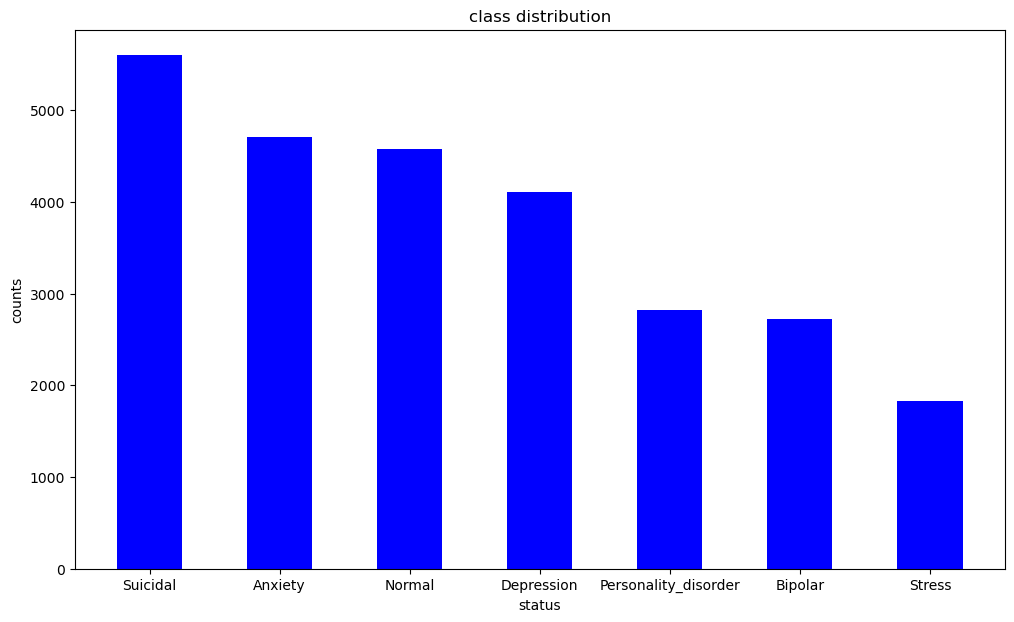

In [29]:
#figure

fig = plt.figure(figsize = (12, 7))
plt.bar(class_counts.index, class_counts.values, color = 'blue',
        width = 0.5)
plt.xlabel("status")
plt.ylabel("counts")
plt.title("class distribution")
plt.show()
                 

## 3. Text Preprocessing

Cleaning the raw text before feeding it into the model. This includes lowercasing, removing URLs, punctuation, emojis, stop words, and lemmatizing each word to its root form.

In [30]:
import re
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\X1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\X1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [31]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [32]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

In [33]:
preprocess("I've been feeling SO anxious lately... can't sleep!! Visit https://mentalhealth.com :)")

'ive feeling anxious lately cant sleep visit'

In [34]:
df['cleaned'] = df['statement'].apply(preprocess)

In [35]:
df.head()

,statement,status,cleaned
0,Anyone else have symptoms much improved after ...,Bipolar,anyone else symptom much improved leaving spou...
1,"I basicaly do not exist, sure feels that way. ...",Suicidal,basicaly exist sure feel way friend realtionsh...
2,Finding a sense of self It's like one minute I...,Personality_disorder,finding sense self like one minute im one pers...
3,Putting into words what were just tangles in m...,Anxiety,putting word tangle brain chronic anxiety toda...
4,Anxiety makes me worry about my public image s...,Anxiety,anxiety make worry public image damn much im f...


In [37]:
print(df['statement'][0])

Anyone else have symptoms much improved after leaving a spouse/SO I don't think I'm "better." I'm still on my meds and see my docs as appropriate, but after leaving my spouse of 15 years 9 months ago, my symptoms have been reduced to almost nothing, and my doctor was able to reduce my medications by 25%.

It certainly helped that I stopped drinking and using pot in that time frame, but I don't think I would have been able to do that in my old relationship. Only now can I look back and see what an emotional burden my ex-SO had been, and how her crazy-making had so severely impacted my emotional health. I don't "blame" her for my mental illness, but I *do* think having her in my life was detrimental to my mental health on so, so many levels. I still feel the occasional phantom twinge of anxiety before I remind myself I don't have to go home to her anymore. I can still sometimes feel my mind running on old tracks laid by her that are of no longer of use to me.

Has anyone else experienced

In [38]:
print(df['cleaned'][0])

anyone else symptom much improved leaving spouseso dont think im better im still med see doc appropriate leaving spouse year month ago symptom reduced almost nothing doctor able reduce medication certainly helped stopped drinking using pot time frame dont think would able old relationship look back see emotional burden exso crazymaking severely impacted emotional health dont blame mental illness think life detrimental mental health many level still feel occasional phantom twinge anxiety remind dont go home anymore still sometimes feel mind running old track laid longer use anyone else experienced notsogreat marriage unhealthy peer group toxic family kept mental illness amped free completely changed outlook experience disease doctor readjust med kind stumbling block face avoid jumping frying pan fire


## 4. Train/Test Split
Defining features and target, then splitting into 80% training and 20% test data.
Stratification is not applied here -- class imbalance is handled at the model level instead.

In [39]:
X = df['cleaned']
Y = df['status']

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.2, random_state=42)

## 5. TF-IDF Vectorisation
Converting cleaned text into numerical features using TF-IDF.
The vectorizer is fit only on training data to prevent data leakage into the test set.
Bigrams are included to capture multi-word phrases common in mental health language.

In [42]:
tfidf = TfidfVectorizer(max_features = 10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [43]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(21080, 10000)
(5270, 10000)


In [45]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 6. Model Training
Logistic Regression with class_weight='balanced' to account for unequal class distribution.
Without balancing, the model would favour high-frequency classes like Normal and Depression.

In [46]:
Y_pred = lr.predict(X_test_tfidf)

## 7. Evaluation
Assessing model performance using precision, recall, and F1-score across all seven classes.
Accuracy alone is not a reliable metric on imbalanced multi-class data.

In [ ]:
print(classification_report(Y_test, Y_pred))

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality_disorder', 'Stress', 'Suicidal']
cm = confusion_matrix(Y_test, Y_pred, labels=labels)


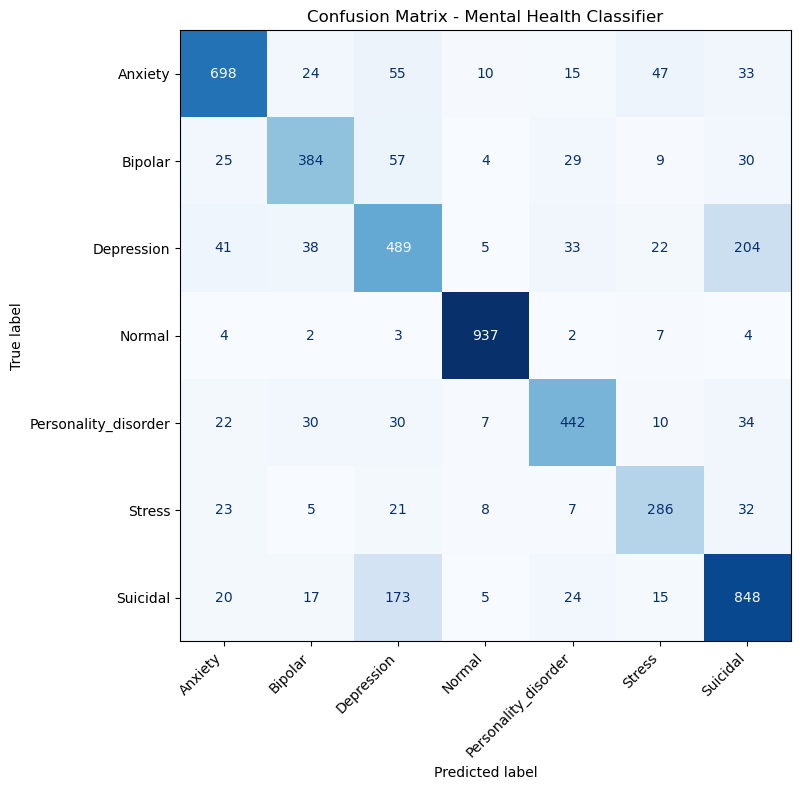

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix - Mental Health Classifier')
plt.tight_layout()
plt.show()

In [51]:
report = classification_report(Y_test, Y_pred, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:-3][['f1-score']]
report_df = report_df.sort_values('f1-score')

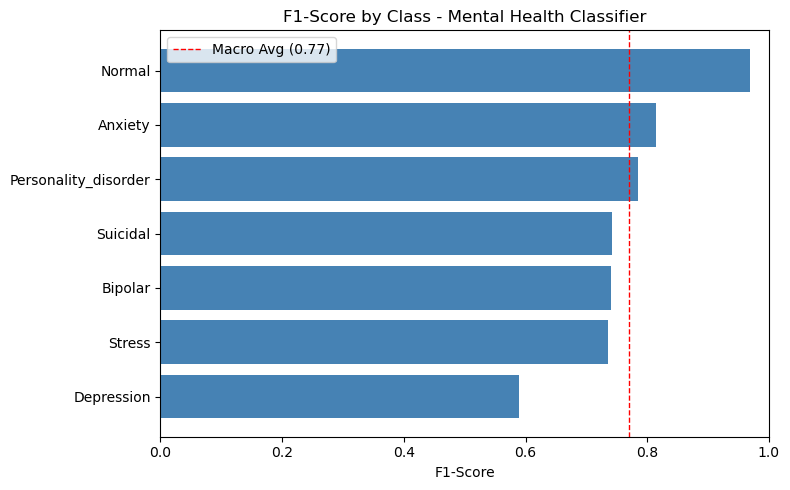

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(report_df.index, report_df['f1-score'], color='steelblue')
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score by Class - Mental Health Classifier')
ax.set_xlim(0, 1)
ax.axvline(x=0.77, color='red', linestyle='--', linewidth=1, label='Macro Avg (0.77)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Conclusions

This project built a complete NLP pipeline to classify mental health statements into
seven categories using TF-IDF vectorisation and Logistic Regression.

**Overall performance:** 77% macro F1-score across all seven classes. For a baseline
model with no deep learning, this is a strong starting point.

**Where the model performs well:** Normal achieves 0.97 F1. The language in normal
posts is distinct enough from clinical categories that the model separates it cleanly.
Anxiety and Personality Disorder also perform well above the macro average.

**Where the model struggles:** Depression has the lowest F1 at 0.59. The confusion
matrix shows that 204 depression posts were misclassified as Suicidal, and 173 suicidal
posts were misclassified as Depression. This is expected. The language across these
categories overlaps heavily. TF-IDF treats words independently and has no way to capture
tone, severity, or context.

**What would improve this model:**
- Replacing TF-IDF with sentence embeddings (e.g. SBERT) or a fine-tuned transformer
  like Mental-BERT would give the model semantic understanding rather than just word counts
- Threshold tuning on the Suicidal class to prioritise recall -- in a real application,
  missing a suicidal post is a more serious failure than a false positive
- Collecting more samples for underrepresented classes like Stress and Bipolar

**Key takeaway:** In a domain like mental health, where misclassification has real consequences, the gap between a baseline and a
production-ready model is measured in safety, not just accuracy.